<img src="https://upload.wikimedia.org/wikipedia/commons/3/35/Uba_fiuba_ingenieria_logo.png" width="300" align="center">

# **Analisis de Series de Tiempo II**
# **Tarea 1, Feature Engineering y Validacion Temporal con GBM**

## Enunciado completo


**Limite de entrega para ser evaluado sobre 100 puntos:** 15 de julio, 23:59 (UTC-3)

Posteriormente pueden enviar la solucion de la tarea, pero cada semana de atraso reduce 10 puntos la evaluacion. Es decir, del 16 de julio 00:00 al 23 de julio 23:59 (UTC-3) se evaluara sobre 90 puntos, y asi sucesivamente hasta el final de la materia.


La tarea se realiza utilizando la serie mensual AirPassengers (pasajeros de aerolineas).

**Parte 1) Feature engineering, 20 puntos**

A partir de la serie "y", deben construir:
* Features de calendario: mes, trimestre, anio, dia_anio, y sus versiones ciclicas (sin/cos) para mes y dia_anio.
* Features con lags [1, 2, 3, 12].
* Features de ventana movil (rolling) de tamano 3 y 12: media, desvio, maximo y minimo, todas con .shift(1) para no filtrar el valor actual.
* Features expansivas (expanding): media y desvio acumulados hasta el periodo anterior.

**Parte 2) Dos conjuntos de features, 5 puntos**

Deben armar dos grupos:
* features_fecha: solo variables de calendario.
* features_all: calendario + lags + rolling + expanding.

**Parte 3) Dos formas de particionar train/test, 5 puntos**

* Holdout temporal: los ultimos 24 meses como test, todo lo anterior como train (respetando el orden cronologico).
* Holdout con shuffle: mismo tamano de test, pero mezclando filas al azar (train_test_split(shuffle=True)).

**Parte 4) Entrenamiento de Gradient Boosting Regressor, 20 puntos**

Deben entrenar un GradientBoostingRegressor para cada combinacion (2 conjuntos de features x 2 tipos de holdout = 4 modelos).

*Usar GradientBoostingRegressor para este ejercicio, no HistGradientBoostingRegressor. Este ultimo esta optimizado para datasets grandes.*

**Parte 5) Metricas, 10 puntos**

Para cada uno de los 4 modelos, calcular MAE, RMSE, MAPE y MASE (usando como referencia el naive estacional de lag 12, es decir, comparar contra "el mismo mes del anio anterior").

**Parte 6) Interpretabilidad, 20 puntos**

Usando el modelo entrenado con features_all en el holdout temporal (el valido, no el de shuffle):

* Calcular la importancia nativa del modelo (feature_importances_) y graficar el top 10.
* Calcular permutation importance sobre el conjunto de test, con scoring="neg_mean_absolute_error" y al menos 30 repeticiones (n_repeats=30), y grafiquen el top 10.
* Comparar ambos rankings.

**Parte 7) Preguntas de analisis, 20 puntos**

* Cual de los dos holdouts refleja mejor el escenario real de uso del modelo (predecir el futuro)? Argumentar en terminos de "el cuando" vs "el que paso".
* En el holdout temporal, comparar features_fecha vs features_all. Cuanto aporta realmente tener lags/rolling frente a usar solo variables de calendario?
* Interpretar el valor de MASE en el holdout temporal: el modelo le gana o le pierde al naive estacional? Que les dice esto sobre la dificultad de mejorar un baseline fuerte en series cortas y muy estacionales?
* Que feature domina el ranking en ambas tecnicas? Por que tiene sentido que sea esa, dada la naturaleza estacional de la serie?

**Entregable: notebook con el codigo corriendo y las respuestas a las 4 preguntas.**

**Link de entrega: [https://forms.gle/AJLpFTwypFJvjYETA](https://forms.gle/AJLpFTwypFJvjYETA)**


## Resolucion

Alumno: Gustavo Julian Rivas -  N° SIU: a1620.

La resolucion se presenta siguiendo cada parte solicitada en el enunciado. 


## Parte 1) Feature engineering

Primero se prepara el entorno, se carga la serie AirPassengers y se construyen las variables solicitadas. El notebook esta pensado para ejecutarse de arriba hacia abajo en Google Colab y no requiere GPU.

La Parte 1 queda resuelta en las celdas siguientes de esta forma:

- La carga de la serie mensual se resuelve en la celda **Carga de datos**, donde se arma el `DataFrame` `df` con indice mensual `ds` y variable objetivo `y`.
- Las features de calendario se resuelven dentro de `add_calendar_features`, donde se crean `mes`, `trimestre`, `anio`, `dia_anio`, `mes_sin`, `mes_cos`, `dia_anio_sin` y `dia_anio_cos`.
- Los lags pedidos se resuelven dentro de `add_lag_features`, que genera `lag_1`, `lag_2`, `lag_3` y `lag_12` a partir de valores pasados de `y`.
- Las ventanas moviles se resuelven dentro de `add_rolling_features`, donde para ventanas 3 y 12 se calculan media, desvio, maximo y minimo. Se aplica `.shift(1)` para que cada fila use solo informacion disponible hasta el periodo anterior.
- Las variables expansivas se resuelven dentro de `add_expanding_features`, donde se calculan `exp_mean` y `exp_std` tambien desplazadas con `.shift(1)`.
- La base final para modelar se construye en `df_model`, eliminando las filas iniciales con `NaN` generadas por lags y ventanas para comparar todos los modelos sobre las mismas fechas.


In [1]:
# Si alguna dependencia no estuviera disponible en Colab, descomentar la linea siguiente.
# !pip install -q pandas numpy matplotlib scikit-learn

import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import GradientBoostingRegressor
from sklearn.inspection import permutation_importance
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

RANDOM_STATE = 42
TEST_SIZE = 24
SEASONAL_PERIOD = 12

plt.style.use("seaborn-v0_8-whitegrid")

### Carga de datos

La consigna propone usar `statsmodels.datasets.get_rdataset("AirPassengers")`. Para que el notebook sea reproducible en Colab aun sin acceso a esa descarga, la serie queda embebida. La serie tiene 144 observaciones mensuales desde enero de 1949 hasta diciembre de 1960.


In [2]:
AIR_PASSENGERS = [
    112, 118, 132, 129, 121, 135, 148, 148, 136, 119, 104, 118,
    115, 126, 141, 135, 125, 149, 170, 170, 158, 133, 114, 140,
    145, 150, 178, 163, 172, 178, 199, 199, 184, 162, 146, 166,
    171, 180, 193, 181, 183, 218, 230, 242, 209, 191, 172, 194,
    196, 196, 236, 235, 229, 243, 264, 272, 237, 211, 180, 201,
    204, 188, 235, 227, 234, 264, 302, 293, 259, 229, 203, 229,
    242, 233, 267, 269, 270, 315, 364, 347, 312, 274, 237, 278,
    284, 277, 317, 313, 318, 374, 413, 405, 355, 306, 271, 306,
    315, 301, 356, 348, 355, 422, 465, 467, 404, 347, 305, 336,
    340, 318, 362, 348, 363, 435, 491, 505, 404, 359, 310, 337,
    360, 342, 406, 396, 420, 472, 548, 559, 463, 407, 362, 405,
    417, 391, 419, 461, 472, 535, 622, 606, 508, 461, 390, 432,
]

df = pd.DataFrame({
    "ds": pd.date_range("1949-01-01", periods=len(AIR_PASSENGERS), freq="MS"),
    "y": AIR_PASSENGERS,
}).set_index("ds")

display(df.head())
display(df.tail())
print(f"Observaciones: {len(df)} | Desde {df.index.min().date()} hasta {df.index.max().date()}")

,y
ds,
1949-01-01,112
1949-02-01,118
1949-03-01,132
1949-04-01,129
1949-05-01,121


,y
ds,
1960-08-01,606
1960-09-01,508
1960-10-01,461
1960-11-01,390
1960-12-01,432


Observaciones: 144 | Desde 1949-01-01 hasta 1960-12-01


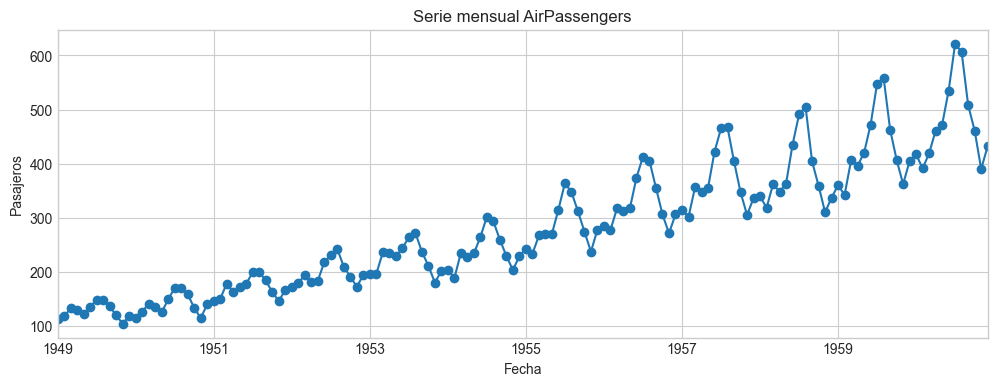

In [3]:
fig, ax = plt.subplots(figsize=(12, 4))
df["y"].plot(ax=ax, marker="o", linewidth=1.5)
ax.set_title("Serie mensual AirPassengers")
ax.set_xlabel("Fecha")
ax.set_ylabel("Pasajeros")
plt.show()

### Construccion de features

Se crean features de calendario, lags, ventanas moviles y ventanas expansivas. En esta celda se concentra la resolucion tecnica de todos los puntos pedidos en la Parte 1.

- `add_calendar_features(data)`: toma el indice temporal mensual y extrae variables de calendario. Las versiones seno/coseno permiten representar ciclos: diciembre y enero quedan cerca entre si en el espacio ciclico, aunque numericamente sean 12 y 1.
- `add_lag_features(data, lags=(1, 2, 3, 12))`: agrega observaciones pasadas de la serie. `lag_1`, `lag_2` y `lag_3` capturan informacion reciente; `lag_12` captura el mismo mes del anio anterior, clave para una serie mensual estacional.
- `add_rolling_features(data, windows=(3, 12))`: resume el comportamiento reciente de la serie con media, desvio, maximo y minimo para ventanas de 3 y 12 meses. Cada resultado se desplaza con `.shift(1)` para que el valor actual `y_t` no se filtre dentro de sus propias features.
- `add_expanding_features(data)`: calcula media y desvio acumulados hasta el periodo anterior. Estas variables aportan una referencia historica del nivel y la dispersion de la serie sin mirar el presente ni el futuro.

Despues de crear todas las variables, `df_features` conserva la serie original mas sus features. Luego `df_model` elimina las filas que quedan incompletas al inicio por los lags y las ventanas, especialmente por `lag_12` y las ventanas de 12 meses.


In [4]:
def add_calendar_features(data):
    out = data.copy()
    idx = out.index

    out["mes"] = idx.month
    out["trimestre"] = idx.quarter
    out["anio"] = idx.year
    out["dia_anio"] = idx.dayofyear

    out["mes_sin"] = np.sin(2 * np.pi * out["mes"] / 12)
    out["mes_cos"] = np.cos(2 * np.pi * out["mes"] / 12)
    out["dia_anio_sin"] = np.sin(2 * np.pi * out["dia_anio"] / 365.25)
    out["dia_anio_cos"] = np.cos(2 * np.pi * out["dia_anio"] / 365.25)

    return out


def add_lag_features(data, lags=(1, 2, 3, 12)):
    out = data.copy()
    for lag in lags:
        out[f"lag_{lag}"] = out["y"].shift(lag)
    return out


def add_rolling_features(data, windows=(3, 12)):
    out = data.copy()
    for window in windows:
        rolling = out["y"].rolling(window=window)
        out[f"roll_mean_{window}"] = rolling.mean().shift(1)
        out[f"roll_std_{window}"] = rolling.std().shift(1)
        out[f"roll_max_{window}"] = rolling.max().shift(1)
        out[f"roll_min_{window}"] = rolling.min().shift(1)
    return out


def add_expanding_features(data):
    out = data.copy()
    out["exp_mean"] = out["y"].expanding().mean().shift(1)
    out["exp_std"] = out["y"].expanding().std().shift(1)
    return out


df_features = (
    df.pipe(add_calendar_features)
      .pipe(add_lag_features)
      .pipe(add_rolling_features)
      .pipe(add_expanding_features)
)

display(df_features.head(15))


,y,mes,trimestre,anio,dia_anio,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos,lag_1,...,roll_mean_3,roll_std_3,roll_max_3,roll_min_3,roll_mean_12,roll_std_12,roll_max_12,roll_min_12,exp_mean,exp_std
ds,,,,,,,,,,,,,,,,,,,,,
1949-01-01,112,1,1,1949,1,5.000000e-01,8.660254e-01,0.017202,0.999852,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
1949-02-01,118,2,1,1949,32,8.660254e-01,5.000000e-01,0.523094,0.852275,112.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,112.000000,NaN
1949-03-01,132,3,1,1949,60,1.000000e+00,6.123234e-17,0.858402,0.512978,118.0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,115.000000,4.242641
1949-04-01,129,4,2,1949,91,8.660254e-01,-5.000000e-01,0.999986,0.005376,132.0,...,120.666667,10.263203,132.0,112.0,NaN,NaN,NaN,NaN,120.666667,10.263203
1949-05-01,121,5,2,1949,121,5.000000e-01,-8.660254e-01,0.872404,-0.488785,129.0,...,126.333333,7.371115,132.0,118.0,NaN,NaN,NaN,NaN,122.750000,9.358597
1949-06-01,135,6,2,1949,152,1.224647e-16,-1.000000e+00,0.502791,-0.864408,121.0,...,127.333333,5.686241,132.0,121.0,NaN,NaN,NaN,NaN,122.400000,8.142481
1949-07-01,148,7,3,1949,182,-5.000000e-01,-8.660254e-01,0.010751,-0.999942,135.0,...,128.333333,7.023769,135.0,121.0,NaN,NaN,NaN,NaN,124.500000,8.916277
1949-08-01,148,8,3,1949,213,-8.660254e-01,-5.000000e-01,-0.499069,-0.866562,148.0,...,134.666667,13.503086,148.0,121.0,NaN,NaN,NaN,NaN,127.857143,12.047525
1949-09-01,136,9,3,1949,244,-1.000000e+00,-1.836970e-16,-0.870294,-0.492533,148.0,...,143.666667,7.505553,148.0,135.0,NaN,NaN,NaN,NaN,130.375000,13.233480


## Parte 2) Dos conjuntos de features

### Resolucion

Se deben armar dos listas de variables para entrenar los modelos con dos niveles de informacion distintos.

`features_fecha` queda formado solamente por las variables de calendario: mes, trimestre, anio, dia del anio y sus codificaciones ciclicas. Este conjunto representa el "cuando" ocurre cada observacion.

`features_all` queda formado por todas las variables disponibles: calendario, lags, rolling windows y expanding windows. Este conjunto agrega informacion historica de la serie al calendario.

El codigo siguiente resuelve esta parte creando explicitamente ambos grupos.


In [5]:
# Resolucion Parte 2: armado explicito de los dos grupos de features pedidos.

# Grupo 1: solo variables de calendario.
features_fecha = [
    "mes", "trimestre", "anio", "dia_anio",
    "mes_sin", "mes_cos", "dia_anio_sin", "dia_anio_cos",
]

# Componentes historicos que se agregan al calendario para formar features_all.
features_lags = ["lag_1", "lag_2", "lag_3", "lag_12"]
features_rolling = [
    f"roll_{stat}_{window}"
    for window in (3, 12)
    for stat in ("mean", "std", "max", "min")
]
features_expanding = ["exp_mean", "exp_std"]

# Grupo 2: calendario + lags + rolling + expanding.
features_all = features_fecha + features_lags + features_rolling + features_expanding

# Se usa una base comun sin NaN para que ambos grupos se comparen sobre las mismas fechas.
df_model = df_features.dropna(subset=features_all + ["y"]).copy()

resumen_features_parte_2 = pd.DataFrame({
    "grupo": (
        ["features_fecha"] * len(features_fecha)
        + ["features_all"] * len(features_all)
    ),
    "feature": features_fecha + features_all,
})

print("Resolucion Parte 2")
print(f"features_fecha: {len(features_fecha)} variables")
print(f"features_all:   {len(features_all)} variables")

print("\nfeatures_fecha se arma aca con:")
print(features_fecha)

print("\nfeatures_all se arma aca con:")
print(features_all)

print(f"\nPrimera fecha modelable: {df_model.index.min().date()}")
print(f"Ultima fecha modelable:  {df_model.index.max().date()}")
print(f"Filas modelables: {len(df_model)}")

display(resumen_features_parte_2)
display(df_model.head())


Resolucion Parte 2
features_fecha: 8 variables
features_all:   22 variables

features_fecha se arma aca con:
['mes', 'trimestre', 'anio', 'dia_anio', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos']

features_all se arma aca con:
['mes', 'trimestre', 'anio', 'dia_anio', 'mes_sin', 'mes_cos', 'dia_anio_sin', 'dia_anio_cos', 'lag_1', 'lag_2', 'lag_3', 'lag_12', 'roll_mean_3', 'roll_std_3', 'roll_max_3', 'roll_min_3', 'roll_mean_12', 'roll_std_12', 'roll_max_12', 'roll_min_12', 'exp_mean', 'exp_std']

Primera fecha modelable: 1950-01-01
Ultima fecha modelable:  1960-12-01
Filas modelables: 132


,grupo,feature
0,features_fecha,mes
1,features_fecha,trimestre
2,features_fecha,anio
3,features_fecha,dia_anio
4,features_fecha,mes_sin
5,features_fecha,mes_cos
6,features_fecha,dia_anio_sin
7,features_fecha,dia_anio_cos
8,features_all,mes
9,features_all,trimestre


,y,mes,trimestre,anio,dia_anio,mes_sin,mes_cos,dia_anio_sin,dia_anio_cos,lag_1,...,roll_mean_3,roll_std_3,roll_max_3,roll_min_3,roll_mean_12,roll_std_12,roll_max_12,roll_min_12,exp_mean,exp_std
ds,,,,,,,,,,,,,,,,,,,,,
1950-01-01,115,1,1,1950,1,0.500000,8.660254e-01,0.017202,0.999852,118.0,...,113.666667,8.386497,119.0,104.0,126.666667,13.720147,148.0,104.0,126.666667,13.720147
1950-02-01,126,2,1,1950,32,0.866025,5.000000e-01,0.523094,0.852275,115.0,...,112.333333,7.371115,118.0,104.0,126.916667,13.453342,148.0,104.0,125.769231,13.528697
1950-03-01,141,3,1,1950,60,1.000000,6.123234e-17,0.858402,0.512978,126.0,...,119.666667,5.686241,126.0,115.0,127.583333,13.166475,148.0,104.0,125.785714,12.998098
1950-04-01,135,4,2,1950,91,0.866025,-5.000000e-01,0.999986,0.005376,141.0,...,127.333333,13.051181,141.0,115.0,128.333333,13.686977,148.0,104.0,126.800000,13.126854
1950-05-01,125,5,2,1950,121,0.500000,-8.660254e-01,0.872404,-0.488785,135.0,...,134.000000,7.549834,141.0,126.0,128.833333,13.822467,148.0,104.0,127.312500,12.846368


## Parte 3) Dos formas de particionar train/test

Se comparan dos particiones. En el holdout temporal, los ultimos 24 meses se reservan como test y todo lo anterior se usa como train. En el holdout con shuffle, se mantiene el mismo tamano de test, pero las filas se mezclan al azar mediante `train_test_split(shuffle=True)`.


Holdout temporal
Train: 1950-01-01 a 1958-12-01 | n=108
Test:  1959-01-01 a 1960-12-01 | n=24


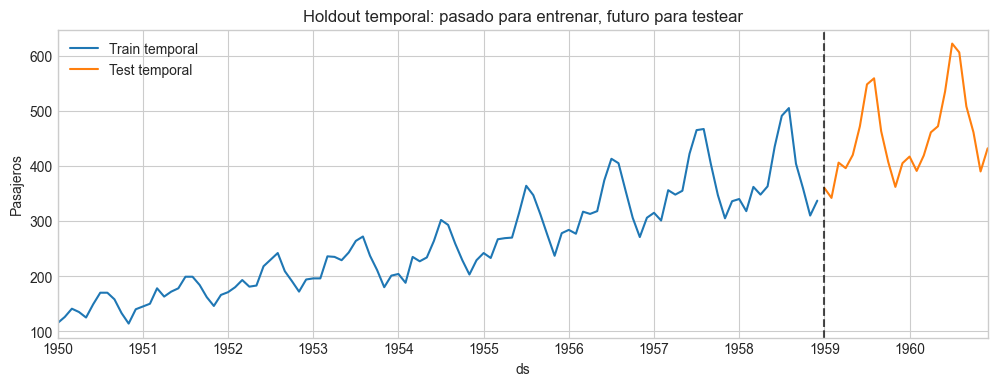

In [6]:
split_position = len(df_model) - TEST_SIZE
train_temporal = df_model.iloc[:split_position].copy()
test_temporal = df_model.iloc[split_position:].copy()

print("Holdout temporal")
print(f"Train: {train_temporal.index.min().date()} a {train_temporal.index.max().date()} | n={len(train_temporal)}")
print(f"Test:  {test_temporal.index.min().date()} a {test_temporal.index.max().date()} | n={len(test_temporal)}")

fig, ax = plt.subplots(figsize=(12, 4))
train_temporal["y"].plot(ax=ax, label="Train temporal")
test_temporal["y"].plot(ax=ax, label="Test temporal", color="tab:orange")
ax.axvline(test_temporal.index.min(), color="black", linestyle="--", alpha=0.7)
ax.set_title("Holdout temporal: pasado para entrenar, futuro para testear")
ax.set_ylabel("Pasajeros")
ax.legend()
plt.show()

## Parte 4) Entrenamiento de Gradient Boosting Regressor

Se entrena `GradientBoostingRegressor` para cada combinacion entre conjunto de features y tipo de holdout. Antes del entrenamiento se definen las funciones de metricas, porque la evaluacion queda integrada en la funcion de entrenamiento.


In [7]:
def mae(y_true, y_pred):
    return mean_absolute_error(y_true, y_pred)


def rmse(y_true, y_pred):
    return np.sqrt(mean_squared_error(y_true, y_pred))


def mape(y_true, y_pred):
    y_true = np.asarray(y_true)
    y_pred = np.asarray(y_pred)
    return np.mean(np.abs((y_true - y_pred) / y_true)) * 100


def mase_scale_from_train(train_y, m=12):
    train_y = pd.Series(train_y).reset_index(drop=True)
    return np.mean(np.abs(train_y.iloc[m:].to_numpy() - train_y.iloc[:-m].to_numpy()))


def evaluate_model(y_true, y_pred, scale):
    model_mae = mae(y_true, y_pred)
    return {
        "MAE": model_mae,
        "RMSE": rmse(y_true, y_pred),
        "MAPE": mape(y_true, y_pred),
        "MASE": model_mae / scale,
    }


mase_scale = mase_scale_from_train(train_temporal["y"], m=SEASONAL_PERIOD)
print(f"Escala MASE naive estacional lag {SEASONAL_PERIOD}: {mase_scale:.3f}")

Escala MASE naive estacional lag 12: 30.521


In [8]:
def make_gbm():
    return GradientBoostingRegressor(
        n_estimators=300,
        learning_rate=0.05,
        max_depth=3,
        subsample=0.9,
        random_state=RANDOM_STATE,
    )


def fit_and_eval(feature_names, holdout_name):
    if holdout_name == "temporal":
        train_data = train_temporal
        test_data = test_temporal
        X_train = train_data[feature_names]
        X_test = test_data[feature_names]
        y_train = train_data["y"]
        y_test = test_data["y"]
    elif holdout_name == "shuffle":
        X_train, X_test, y_train, y_test = train_test_split(
            df_model[feature_names],
            df_model["y"],
            test_size=TEST_SIZE,
            shuffle=True,
            random_state=RANDOM_STATE,
        )
    else:
        raise ValueError("holdout_name debe ser 'temporal' o 'shuffle'")

    model = make_gbm()
    model.fit(X_train, y_train)
    pred = model.predict(X_test)
    metrics = evaluate_model(y_test, pred, mase_scale)

    return {
        "model": model,
        "X_train": X_train,
        "X_test": X_test,
        "y_train": y_train,
        "y_test": y_test,
        "pred": pd.Series(pred, index=y_test.index, name="pred"),
        "metrics": metrics,
    }

experiments = {}
rows = []

feature_sets = {
    "features_fecha": features_fecha,
    "features_all": features_all,
}

for feature_set_name, feature_names in feature_sets.items():
    for holdout_name in ["temporal", "shuffle"]:
        result = fit_and_eval(feature_names, holdout_name)
        experiments[(feature_set_name, holdout_name)] = result
        rows.append({
            "features": feature_set_name,
            "holdout": holdout_name,
            **result["metrics"],
        })

results = (
    pd.DataFrame(rows)
      .sort_values(["holdout", "MASE"])
      .reset_index(drop=True)
)

display(results.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "MAPE": "{:.2f}", "MASE": "{:.3f}"}))

,features,holdout,MAE,RMSE,MAPE,MASE
0,features_all,shuffle,7.567,9.438,3.62,0.248
1,features_fecha,shuffle,10.499,14.125,4.52,0.344
2,features_all,temporal,47.800,59.110,9.90,1.566
3,features_fecha,temporal,71.805,78.282,15.60,2.353


## Parte 5) Metricas

Para cada uno de los cuatro modelos se calculan MAE, RMSE, MAPE y MASE. MASE se calcula con una escala fija obtenida desde el naive estacional de lag 12 sobre el entrenamiento temporal, de modo que todos los modelos se comparan contra la misma referencia.


In [9]:
display(results.style.format({"MAE": "{:.3f}", "RMSE": "{:.3f}", "MAPE": "{:.2f}", "MASE": "{:.3f}"}))


,features,holdout,MAE,RMSE,MAPE,MASE
0,features_all,shuffle,7.567,9.438,3.62,0.248
1,features_fecha,shuffle,10.499,14.125,4.52,0.344
2,features_all,temporal,47.800,59.110,9.90,1.566
3,features_fecha,temporal,71.805,78.282,15.60,2.353


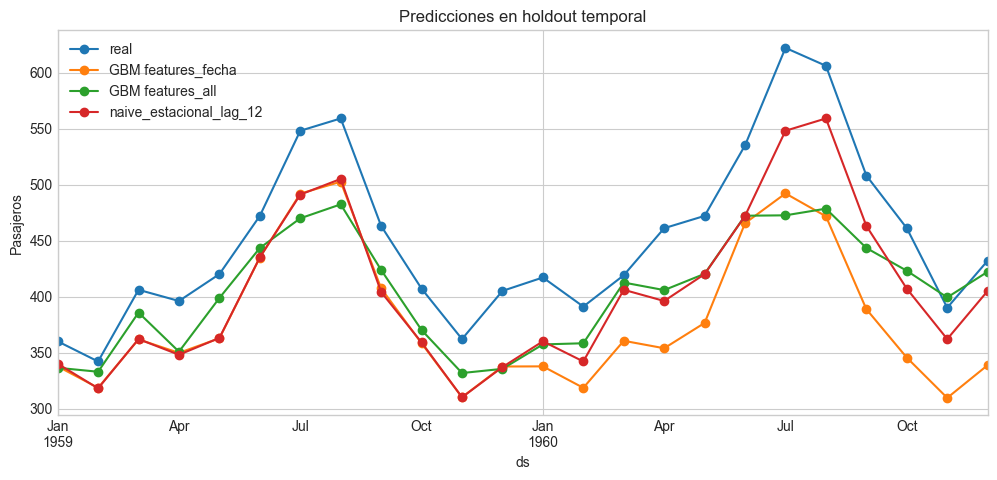

,real,GBM features_fecha,GBM features_all,naive_estacional_lag_12
ds,,,,
1959-01-01,360,337.627787,336.355776,340.0
1959-02-01,342,318.459046,332.829272,318.0
1959-03-01,406,361.734442,385.664317,362.0
1959-04-01,396,349.671553,350.750348,348.0
1959-05-01,420,362.720945,398.688981,363.0


In [10]:
temporal_plot = pd.DataFrame({
    "real": test_temporal["y"],
    "GBM features_fecha": experiments[("features_fecha", "temporal")]["pred"].sort_index(),
    "GBM features_all": experiments[("features_all", "temporal")]["pred"].sort_index(),
    "naive_estacional_lag_12": df_features.loc[test_temporal.index, "lag_12"],
})

fig, ax = plt.subplots(figsize=(12, 5))
temporal_plot.plot(ax=ax, marker="o")
ax.set_title("Predicciones en holdout temporal")
ax.set_ylabel("Pasajeros")
ax.legend()
plt.show()

display(temporal_plot.head())

## Parte 6) Interpretabilidad

La interpretabilidad se calcula sobre el modelo entrenado con `features_all` y holdout temporal, que es la combinacion valida para simular prediccion futura. Se grafica el top 10 de importancia nativa y el top 10 de permutation importance sobre test temporal con `scoring="neg_mean_absolute_error"` y `n_repeats=30`.


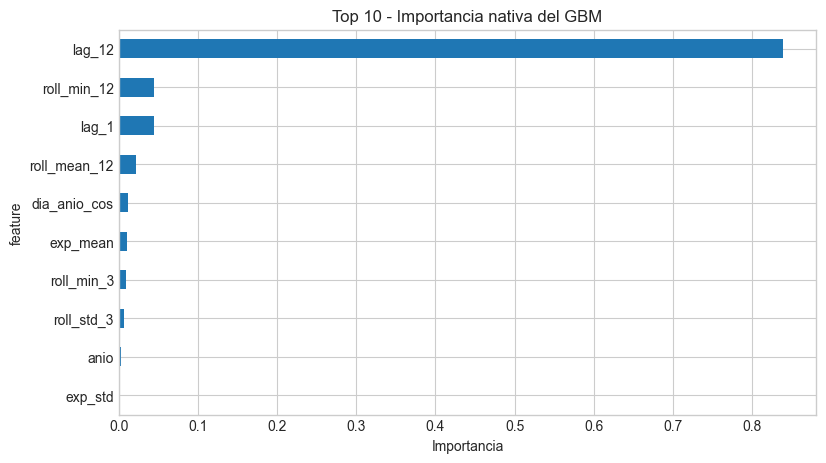

,feature,importance
0,lag_12,0.839264
1,roll_min_12,0.045024
2,lag_1,0.044501
3,roll_mean_12,0.021412
4,dia_anio_cos,0.011640
5,exp_mean,0.009918
6,roll_min_3,0.008838
7,roll_std_3,0.006168
8,anio,0.003415
9,exp_std,0.001701


In [11]:
valid_result = experiments[("features_all", "temporal")]
valid_model = valid_result["model"]
X_test_valid = valid_result["X_test"]
y_test_valid = valid_result["y_test"]

native_importance = (
    pd.DataFrame({
        "feature": features_all,
        "importance": valid_model.feature_importances_,
    })
    .sort_values("importance", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
native_importance.head(10).sort_values("importance").plot.barh(
    x="feature", y="importance", ax=ax, legend=False
)
ax.set_title("Top 10 - Importancia nativa del GBM")
ax.set_xlabel("Importancia")
plt.show()

display(native_importance.head(10))

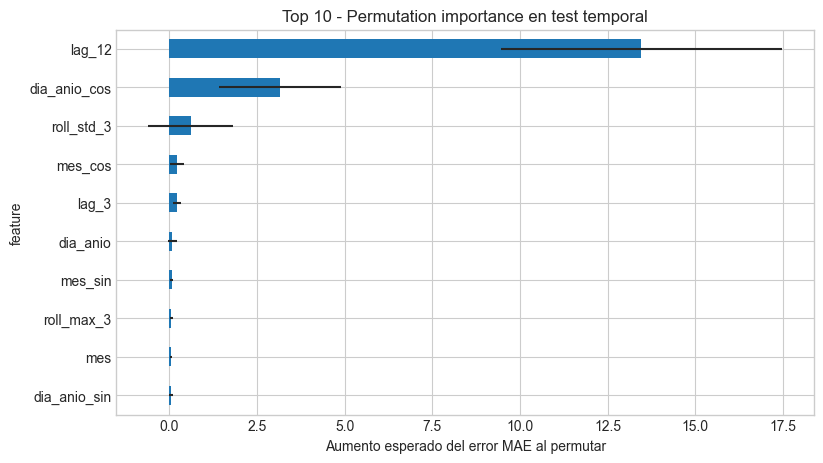

,feature,importance_mean,importance_std
0,lag_12,13.466868,4.013306
1,dia_anio_cos,3.147868,1.737005
2,roll_std_3,0.614364,1.216067
3,mes_cos,0.228962,0.197031
4,lag_3,0.216313,0.111130
5,dia_anio,0.088858,0.123683
6,mes_sin,0.071877,0.043690
7,roll_max_3,0.064054,0.047233
8,mes,0.062170,0.028580
9,dia_anio_sin,0.060572,0.056435


In [12]:
perm = permutation_importance(
    valid_model,
    X_test_valid,
    y_test_valid,
    scoring="neg_mean_absolute_error",
    n_repeats=30,
    random_state=RANDOM_STATE,
)

permutation_df = (
    pd.DataFrame({
        "feature": features_all,
        "importance_mean": perm.importances_mean,
        "importance_std": perm.importances_std,
    })
    .sort_values("importance_mean", ascending=False)
    .reset_index(drop=True)
)

fig, ax = plt.subplots(figsize=(9, 5))
permutation_df.head(10).sort_values("importance_mean").plot.barh(
    x="feature", y="importance_mean", ax=ax, legend=False, xerr="importance_std"
)
ax.set_title("Top 10 - Permutation importance en test temporal")
ax.set_xlabel("Aumento esperado del error MAE al permutar")
plt.show()

display(permutation_df.head(10))

## Parte 7) Preguntas de analisis

La siguiente celda arma una lectura cuantitativa a partir de los resultados calculados arriba. Luego se responden las cuatro preguntas conceptuales solicitadas.


In [13]:
temporal_results = results[results["holdout"] == "temporal"].set_index("features")
shuffle_results = results[results["holdout"] == "shuffle"].set_index("features")

mae_fecha = temporal_results.loc["features_fecha", "MAE"]
mae_all = temporal_results.loc["features_all", "MAE"]
mase_all = temporal_results.loc["features_all", "MASE"]
mejora_mae = (mae_fecha - mae_all) / mae_fecha * 100

top_native = native_importance.iloc[0]["feature"]
top_perm = permutation_df.iloc[0]["feature"]

print("Resumen para responder preguntas")
print("- Holdout temporal: representa predecir futuro usando pasado.")
print("- Holdout shuffle: mezcla fechas; sirve como contraste, no como validacion real de forecasting.")
print(f"- MAE temporal features_fecha: {mae_fecha:.3f}")
print(f"- MAE temporal features_all:   {mae_all:.3f}")
print(f"- Cambio relativo de MAE al agregar lags/rolling/expanding: {mejora_mae:.2f}%")
print(f"- MASE temporal features_all: {mase_all:.3f}")
print("  Interpretacion MASE: < 1 mejora al naive estacional; > 1 pierde contra ese baseline.")
print(f"- Feature top en importancia nativa: {top_native}")
print(f"- Feature top en permutation importance: {top_perm}")

Resumen para responder preguntas
- Holdout temporal: representa predecir futuro usando pasado.
- Holdout shuffle: mezcla fechas; sirve como contraste, no como validacion real de forecasting.
- MAE temporal features_fecha: 71.805
- MAE temporal features_all:   47.800
- Cambio relativo de MAE al agregar lags/rolling/expanding: 33.43%
- MASE temporal features_all: 1.566
  Interpretacion MASE: < 1 mejora al naive estacional; > 1 pierde contra ese baseline.
- Feature top en importancia nativa: lag_12
- Feature top en permutation importance: lag_12


### Pregunta 1: holdout temporal vs holdout con shuffle

El holdout temporal refleja mejor el escenario real de uso del modelo, porque en forecasting se entrena con pasado y se predice futuro. Este esquema respeta el "cuando": al momento de predecir los ultimos 24 meses, el modelo solo pudo haber observado informacion anterior.

El holdout con shuffle mezcla filas al azar. Eso puede hacer que fechas futuras queden en entrenamiento y fechas pasadas queden en test. Aunque no se use directamente la variable objetivo futura como feature, se rompe la estructura temporal del problema y se contamina la evaluacion: ya no se mide una prediccion futura realista, sino la capacidad de reconocer patrones globales de la serie con informacion temporal mezclada.

### Pregunta 2: features_fecha vs features_all en holdout temporal

`features_fecha` captura solamente el calendario: mes, trimestre, anio, dia del anio y codificaciones ciclicas. Estas variables representan el "cuando" y permiten aprender estacionalidad.

`features_all` agrega lags, rolling windows y expanding windows. Esas variables representan el "que venia pasando": nivel reciente, estacionalidad del mismo mes del anio anterior, tendencia local y variabilidad historica. El aporte concreto de estas variables se observa comparando las metricas del holdout temporal en la tabla de resultados y en el resumen cuantitativo anterior.

### Pregunta 3: interpretacion de MASE

MASE compara el error del modelo contra el error promedio de un naive estacional de lag 12. En esta serie, ese baseline es fuerte porque AirPassengers tiene una estacionalidad anual muy marcada.

- Si MASE < 1, el modelo mejora al naive estacional.
- Si MASE = 1, el modelo empata aproximadamente con el naive estacional.
- Si MASE > 1, el modelo pierde contra el naive estacional.

Si un GBM no mejora ampliamente a este baseline, el resultado sigue siendo razonable: la serie es corta, mensual, muy estacional y con tendencia creciente. Mejorar un naive estacional fuerte exige capturar nivel, tendencia y estacionalidad sin sobreajustar.

### Pregunta 4: feature dominante en los rankings

La feature dominante se interpreta comparando la importancia nativa con permutation importance. En esta tarea es esperable que aparezcan arriba variables ligadas al mismo mes del anio anterior, especialmente `lag_12`, o features de calendario/ciclo anual. Tiene sentido porque la serie AirPassengers presenta un patron anual muy marcado: los meses altos y bajos tienden a repetirse cada anio, aunque sobre un nivel creciente.


## Conclusiones

La resolucion muestra que, para una serie temporal, la forma de validacion es tan importante como el modelo utilizado. El holdout temporal es el esquema que representa el uso real del modelo, porque entrena con observaciones pasadas y evalua sobre meses futuros. En cambio, el holdout con shuffle se incluye para cumplir la consigna y como contraste metodologico, pero no debe tomarse como estimacion principal del desempeno en forecasting porque mezcla momentos de la serie y rompe la logica temporal del problema.

El feature engineering se construyo manteniendo una condicion central: cada fila debe usar solamente información disponible hasta el periodo anterior. Por eso los lags miran valores pasados y las variables rolling y expanding se desplazan con `.shift(1)`. Esta decisión evita leakage temporal y hace que las features sean utilizables en un escenario real de prediccion futura.

La comparación entre `features_fecha` y `features_all` permite separar dos tipos de información. `features_fecha` resume el calendario y captura el "cuando" de la observación, especialmente la estacionalidad mensual. `features_all` agrega el "que venia pasando" mediante lags, ventanas moviles y estadisticos expansivos. En una serie como AirPassengers, donde existe tendencia creciente y estacionalidad anual marcada, esa información historica resulta relevante para representar tanto el nivel reciente como el patron del mismo mes del año anterior.

MASE aporta una lectura mas exigente que las metricas de error absolutas, porque compara el GBM contra un naive estacional de lag 12. Ese baseline es fuerte para AirPassengers: repetir el valor del mismo mes del año anterior ya incorpora buena parte de la estructura estacional. Por eso, si el modelo apenas mejora o incluso pierde contra esa referencia, no necesariamente indica una mala implementación; también refleja que la serie es corta, muy estacional y dificil de superar sin sobreajustar.

La interpretabilidad completa el analisis al revisar si el modelo usa señales coherentes con el problema. Si aparecen arriba variables como `lag_12` o codificaciones ciclicas del calendario, el resultado es consistente con la naturaleza mensual y estacional de la serie. De esta forma, la entrega no solo entrena modelos y calcula metricas, sino que también verifica que la evaluación, las features y la lectura final respeten el comportamiento temporal de los datos.
